# Activity State — the maths
Lightweight, orientation-proof features built from the RAW signals (no 561 features).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

base = "/home/voare/Documents/Synheart/Kinematics/Dataset/UCI HAR Dataset"
sig  = base + "/train/Inertial Signals"

def load(name):                                  # each file = (7352 windows, 128 samples)
    return pd.read_csv(f"{sig}/{name}_train.txt", sep=r"\s+", header=None).to_numpy()

# raw accelerometer, 3 axes
ax = load("body_acc_x")
ay = load("body_acc_y")
az = load("body_acc_z")

# the activity label per window
names = pd.read_csv(base + "/activity_labels.txt", sep=r"\s+", header=None, index_col=0)[1]
y = pd.read_csv(base + "/train/y_train.txt", header=None)[0].map(names)

print("raw acc shape:", ax.shape, "(windows, samples)")

raw acc shape: (7352, 128) (windows, samples)


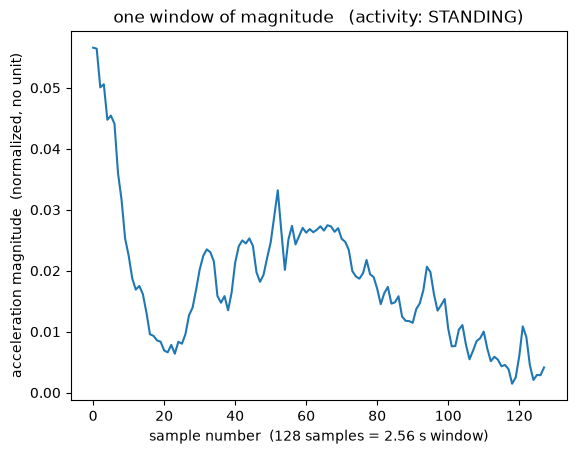

In [2]:
# magnitude = sqrt(x^2 + y^2 + z^2): squish 3 axes into ONE number.
# this is the key trick -> the same no matter how the phone is rotated.
mag = np.sqrt(ax**2 + ay**2 + az**2)             # shape (7352, 128)

# look at ONE window of magnitude over time
plt.plot(mag[0])
plt.xlabel("sample number  (128 samples = 2.56 s window)")     # x = time inside the window
plt.ylabel("acceleration magnitude  (normalized, no unit)")    # y = how strong the motion is
plt.title(f"one window of magnitude   (activity: {y[0]})")
plt.show()

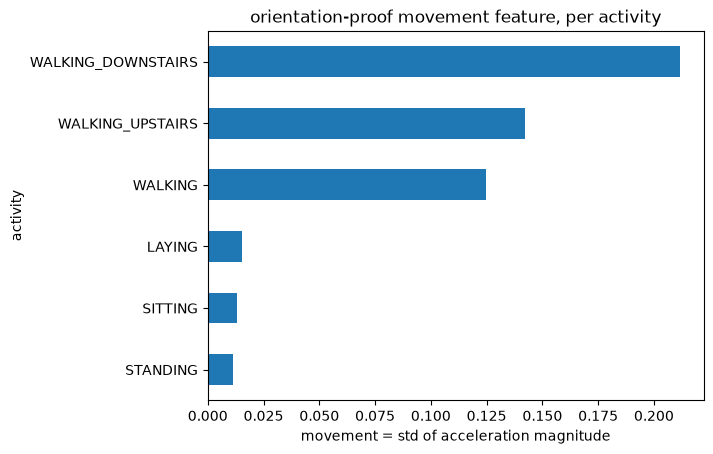

In [3]:
# our FIRST orientation-proof feature:
# movement = how much the magnitude wobbles in the window (std)
movement = mag.std(axis=1)                        # one number per window

# does it separate still vs moving? average per activity
df = pd.DataFrame({"activity": y, "movement": movement})
df.groupby("activity")["movement"].mean().sort_values().plot(kind="barh")
plt.xlabel("movement = std of acceleration magnitude")   # x = our feature value
plt.ylabel("activity")                                   # y = activity
plt.title("orientation-proof movement feature, per activity")
plt.show()

## Rhythm / Movement Regularity
How repeating the motion is, from the autocorrelation of the magnitude.

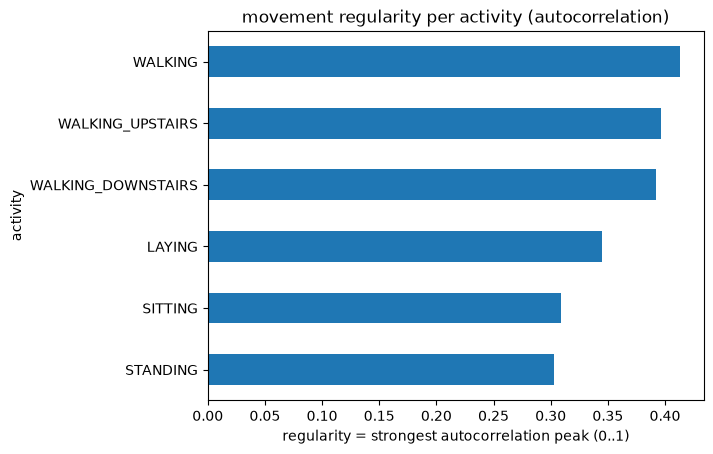

In [4]:
# regularity = strongest autocorrelation peak (0..1);  cadence = strides per second
def reg_cad(m):
    m = m - m.mean()
    ac = np.correlate(m, m, mode="full")[len(m)-1:]   # autocorrelation, lags 0..127
    if ac[0] == 0:
        return 0.0, np.nan
    ac = ac / ac[0]                                    # normalize so lag 0 = 1
    seg = ac[10:64]                                    # skip central lobe; search real rhythms
    k = 10 + int(np.argmax(seg))
    return float(seg.max()), 50.0 / k                  # 50 Hz sampling -> per second

vals = np.array([reg_cad(mag[i]) for i in range(len(mag))])
regularity, cadence = vals[:, 0], vals[:, 1]

pd.DataFrame({"activity": y, "regularity": regularity}) \
  .groupby("activity")["regularity"].mean().sort_values().plot(kind="barh")
plt.xlabel("regularity = strongest autocorrelation peak (0..1)")   # x = feature value
plt.ylabel("activity")                                             # y = activity
plt.title("movement regularity per activity (autocorrelation)")
plt.show()

### The real regularity = movement + rhythm together
"Regular" means **calm** (low movement) OR **rhythmic** (high autocorrelation).
Autocorrelation alone misses the calm kind, so we read both at once:

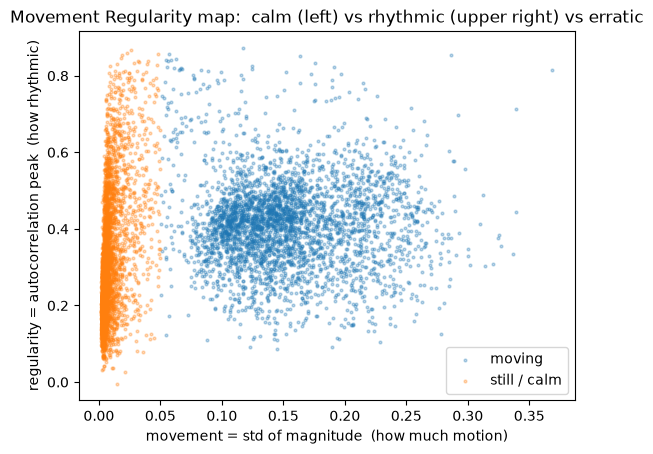

In [5]:
# map every window: how much movement (x) vs how rhythmic (y)
still = movement < 0.05                              # our still/moving line

plt.scatter(movement[~still], regularity[~still], s=4, alpha=0.3, label="moving")
plt.scatter(movement[still],  regularity[still],  s=4, alpha=0.3, label="still / calm")
plt.xlabel("movement = std of magnitude  (how much motion)")   # x = amount of motion
plt.ylabel("regularity = autocorrelation peak  (how rhythmic)") # y = how repeating
plt.title("Movement Regularity map:  calm (left) vs rhythmic (upper right) vs erratic")
plt.legend()
plt.show()

# reading: low movement = calm/regular; high movement + high regularity = rhythmic/regular;
#          high movement + low regularity = erratic/irregular (fidget, agitation)

## Finalize — Activity State classifier + the rotation test (the proof)
Map UCI-HAR to 3 activity states: **sedentary** (sit/lay), **standing**, **walking** (all walks).

In [6]:
from scipy.spatial.transform import Rotation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def load_split(split):
    pth = f"{base}/{split}/Inertial Signals"
    chans = ["body_acc_x","body_acc_y","body_acc_z","body_gyro_x","body_gyro_y","body_gyro_z",
             "total_acc_x","total_acc_y","total_acc_z"]
    sig = {c: pd.read_csv(f"{pth}/{c}_{split}.txt", sep=r"\s+", header=None).to_numpy() for c in chans}
    lab = pd.read_csv(f"{base}/{split}/y_{split}.txt", header=None)[0].map(names)
    act = lab.replace({"SITTING":"sedentary","LAYING":"sedentary","STANDING":"standing",
                       "WALKING":"walking","WALKING_UPSTAIRS":"walking","WALKING_DOWNSTAIRS":"walking"})
    return sig, act.to_numpy()

def reg_peak(m):
    m = m - m.mean(); ac = np.correlate(m, m, mode="full")[len(m)-1:]
    if ac[0] == 0: return 0.0
    return float((ac/ac[0])[10:64].max())

def feats_invariant(s):       # OURS: magnitude-based -> orientation-proof
    macc = np.sqrt(s["body_acc_x"]**2 + s["body_acc_y"]**2 + s["body_acc_z"]**2)
    mgyr = np.sqrt(s["body_gyro_x"]**2 + s["body_gyro_y"]**2 + s["body_gyro_z"]**2)
    reg  = np.array([reg_peak(macc[i]) for i in range(len(macc))])
    return np.column_stack([macc.mean(1), macc.std(1), mgyr.mean(1), mgyr.std(1), reg])

def feats_coupled(s):         # HENOK-STYLE: per-axis -> orientation-dependent
    return np.column_stack([s["total_acc_x"].mean(1), s["total_acc_y"].mean(1), s["total_acc_z"].mean(1),
                            s["body_acc_x"].std(1),   s["body_acc_y"].std(1),   s["body_acc_z"].std(1)])

def rotate_all(s, seed=0):    # random 3D rotation per window = different phone placements
    rng = np.random.default_rng(seed); N = s["body_acc_x"].shape[0]
    out = {k: np.empty_like(v) for k, v in s.items()}
    triples = [("body_acc_x","body_acc_y","body_acc_z"),("body_gyro_x","body_gyro_y","body_gyro_z"),
               ("total_acc_x","total_acc_y","total_acc_z")]
    for i in range(N):
        R = Rotation.random(random_state=rng).as_matrix()
        for t in triples:
            r = R @ np.stack([s[t[0]][i], s[t[1]][i], s[t[2]][i]])
            for j, n in enumerate(t): out[n][i] = r[j]
    return out

tr, y_tr = load_split("train")
te, y_te = load_split("test")
print("Activity State classes:", sorted(set(y_tr)))

Activity State classes: ['sedentary', 'standing', 'walking']


In [7]:
# DETERMINISTIC rule -- no training, just ONE threshold read off the data
def activity_rule(s):
    macc = np.sqrt(s["body_acc_x"]**2 + s["body_acc_y"]**2 + s["body_acc_z"]**2)
    movement = macc.std(axis=1)                       # orientation-proof "how much motion"
    return np.where(movement > 0.05, "walking", "sedentary")

pred = activity_rule(te)
print("DETERMINISTIC rule (1 threshold):")
print("  3-class accuracy :", round(accuracy_score(y_te, pred)*100, 1), "%")
sw_t = np.where(y_te == "walking", "walking", "still")
sw_p = np.where(pred  == "walking", "walking", "still")
print("  still-vs-walking :", round(accuracy_score(sw_t, sw_p)*100, 1), "%   <- what movement actually decides")
print(pd.crosstab(pd.Series(y_te, name="true"), pd.Series(pred, name="pred")))
# standing vs sedentary = posture (gravity direction) = the Postural-State task,
# so an orientation-proof movement rule folds standing into 'still'. Expected, not a bug.

DETERMINISTIC rule (1 threshold):
  3-class accuracy : 80.7 %
  still-vs-walking : 98.2 %   <- what movement actually decides
pred       sedentary  walking
true                         
sedentary        991       37
standing         517       15
walking            0     1387


### The rotation test — does it survive a rotated phone?
Spin every test window by a random 3D rotation (different placements) and re-measure.

                           clean  rotated
ours (deterministic rule)   80.7     80.7
coupled (per-axis)          93.2     54.8


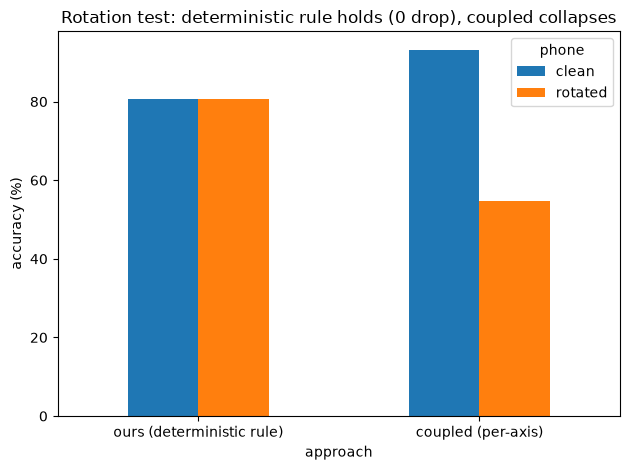

In [8]:
te_rot = rotate_all(te, seed=0)        # everyone wears the phone at a random angle

# OURS: deterministic rule on an invariant feature -> CANNOT move, since ||Ra|| = ||a||
ours = [accuracy_score(y_te, activity_rule(te))*100,
        accuracy_score(y_te, activity_rule(te_rot))*100]

# CONTRAST: orientation-coupled (per-axis) features -> collapse
mc = RandomForestClassifier(n_estimators=100, random_state=0).fit(feats_coupled(tr), y_tr)
coup = [accuracy_score(y_te, mc.predict(feats_coupled(te)))*100,
        accuracy_score(y_te, mc.predict(feats_coupled(te_rot)))*100]

res = pd.DataFrame({"ours (deterministic rule)": ours, "coupled (per-axis)": coup},
                   index=["clean", "rotated"]).T
print(res.round(1))

res.plot(kind="bar")
plt.ylabel("accuracy (%)")          # y = accuracy
plt.xlabel("approach")              # x = which approach
plt.title("Rotation test: deterministic rule holds (0 drop), coupled collapses")
plt.xticks(rotation=0); plt.legend(title="phone"); plt.tight_layout()
plt.show()

## PROOF: rotate the phone -> per-axis changes, magnitude does NOT
Same body-accel window, mounted at a random angle. Watch the X-axis move and the magnitude stay put.

X-axis, first 5 samples  BEFORE: [0.0002 0.0101 0.0093 0.0051 0.0108]
X-axis, first 5 samples  AFTER : [-0.0125 -0.0025 -0.0041 -0.0062 -0.0006]   <- per-axis CHANGED

magnitude, first 5  BEFORE: [0.0566 0.0564 0.0501 0.0506 0.0448]
magnitude, first 5  AFTER : [0.0566 0.0564 0.0501 0.0506 0.0448]   <- magnitude SAME

biggest magnitude difference anywhere: 1.3877787807814457e-17


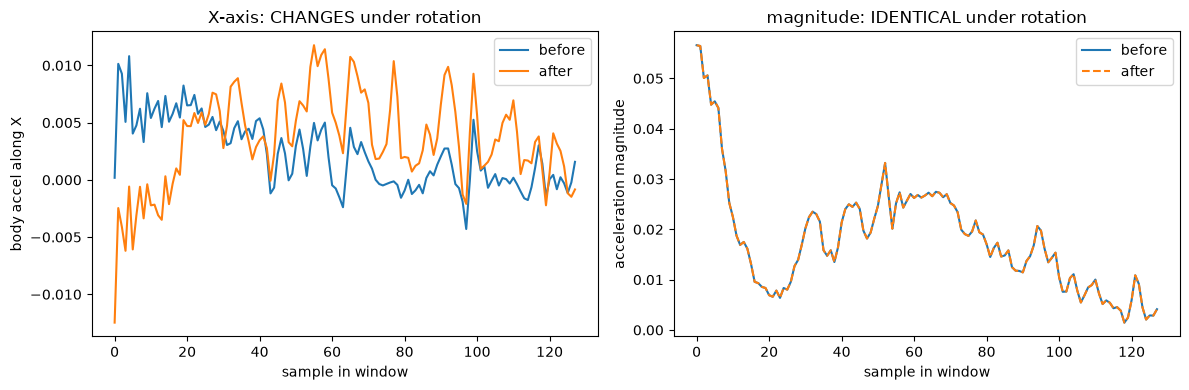

In [9]:
from scipy.spatial.transform import Rotation

w = 0                                              # pick one window
xyz = np.stack([ax[w], ay[w], az[w]])              # (3,128): the X, Y, Z body-accel signals

R = Rotation.random(random_state=1).as_matrix()    # phone mounted at a random angle
xyz_rot = R @ xyz                                   # SAME motion, rotated device

mag_before = np.sqrt((xyz**2).sum(0))              # magnitude per sample = sqrt(x^2+y^2+z^2)
mag_after  = np.sqrt((xyz_rot**2).sum(0))

print("X-axis, first 5 samples  BEFORE:", np.round(xyz[0, :5], 4))
print("X-axis, first 5 samples  AFTER :", np.round(xyz_rot[0, :5], 4), "  <- per-axis CHANGED")
print()
print("magnitude, first 5  BEFORE:", np.round(mag_before[:5], 4))
print("magnitude, first 5  AFTER :", np.round(mag_after[:5], 4), "  <- magnitude SAME")
print()
print("biggest magnitude difference anywhere:", np.abs(mag_before - mag_after).max())

fig, a = plt.subplots(1, 2, figsize=(12, 4))
a[0].plot(xyz[0], label="before"); a[0].plot(xyz_rot[0], label="after")
a[0].set_title("X-axis: CHANGES under rotation")
a[0].set_xlabel("sample in window"); a[0].set_ylabel("body accel along X"); a[0].legend()
a[1].plot(mag_before, label="before"); a[1].plot(mag_after, "--", label="after")
a[1].set_title("magnitude: IDENTICAL under rotation")
a[1].set_xlabel("sample in window"); a[1].set_ylabel("acceleration magnitude"); a[1].legend()
plt.tight_layout(); plt.show()

## MotionSense — primary bench (adds running)
iPhone 6s in a front trouser pocket, 50 Hz. The accelerometer channel here is
`userAcceleration.*`: body motion with gravity already removed by iOS. The recordings are
continuous, so we cut our own windows (128 samples = 2.56 s, 50% overlap) and split by
**subject** — no person appears in both train and test. This adds a `running` class on top
of UCI-HAR's still / walking, classified by a second threshold on energy.

In [10]:
import os, glob
from sklearn.metrics import classification_report

ms_root = "/home/voare/Documents/Synheart/Kinematics/Dataset/MotionSense/A_DeviceMotion_data/A_DeviceMotion_data"
code2state = {"sit":"sedentary", "std":"standing", "wlk":"walking", "jog":"running"}  # dws/ups = stairs (locomotion), set aside

def ms_windows(a, n=128, step=64):                # 2.56 s windows, 50% overlap
    return np.stack([a[i:i+n] for i in range(0, len(a)-n+1, step)]) if len(a) >= n else np.empty((0, n))

rows = []
for folder in sorted(os.listdir(ms_root)):
    code = folder.split("_")[0]                   # "wlk_7" -> "wlk"
    if code not in code2state:
        continue
    for f in glob.glob(f"{ms_root}/{folder}/sub_*.csv"):
        subj = int(os.path.basename(f)[4:-4])     # "sub_19.csv" -> 19
        d = pd.read_csv(f)
        # userAcceleration = body accel, gravity already removed by iOS -> magnitude is orientation-proof
        mag = np.sqrt(d["userAcceleration.x"]**2 + d["userAcceleration.y"]**2 + d["userAcceleration.z"]**2).to_numpy()
        for w in ms_windows(mag):
            _, cad = reg_cad(w)                    # cadence (Hz), reused from the regularity section -> walk/run tiebreaker in Loop 3
            rows.append((code2state[code], subj, w.std(), w.mean(), cad))   # movement (std), energy (mean), cadence

ms = pd.DataFrame(rows, columns=["state", "subj", "movement", "mean_mag", "cad"])
print("MotionSense windows:", len(ms))
print(ms["state"].value_counts())

MotionSense windows: 17237
state
walking      5275
sedentary    5221
standing     4716
running      2025
Name: count, dtype: int64


In [11]:
# subject-independent split: hold out 6 people the rule never sees
# (ms_ prefix so these never collide with the UCI-HAR tr/te above)
test_subs = {19, 20, 21, 22, 23, 24}
ms_tr = ms[~ms["subj"].isin(test_subs)]
ms_te = ms[ ms["subj"].isin(test_subs)]
print(f"train windows {len(ms_tr)}  |  test windows {len(ms_te)}  (held-out subjects {sorted(test_subs)})\n")

# RE-DERIVE the thresholds on MotionSense -- UCI-HAR's 0.05 does NOT transfer (different units/preproc)
print("median per state, TRAIN subjects:")
print(ms_tr.groupby("state")[["movement","mean_mag"]].median().round(3), "\n")
print("still ceiling : standing movement 95% =", round(ms_tr[ms_tr.state=='standing'].movement.quantile(.95), 3),
      " | walking movement 5% =",                round(ms_tr[ms_tr.state=='walking' ].movement.quantile(.05), 3))
print("walk/run line : walking mean_mag 95% =", round(ms_tr[ms_tr.state=='walking'].mean_mag.quantile(.95), 3),
      " | running mean_mag 5% =",                round(ms_tr[ms_tr.state=='running'].mean_mag.quantile(.05), 3))

# the two thresholds, read straight off the gaps above
T_STILL = 0.10   # movement below this = still  (sedentary; standing folds in, postural_state owns it)
T_RUN   = 1.00   # while moving, energy above this = running, else walking

train windows 12896  |  test windows 4341  (held-out subjects [19, 20, 21, 22, 23, 24])

median per state, TRAIN subjects:
           movement  mean_mag
state                        
running       0.789     1.517
sedentary     0.004     0.018
standing      0.012     0.041
walking       0.419     0.709 

still ceiling : standing movement 95% = 0.041  | walking movement 5% = 0.195
walk/run line : walking mean_mag 95% = 0.965  | running mean_mag 5% = 0.988


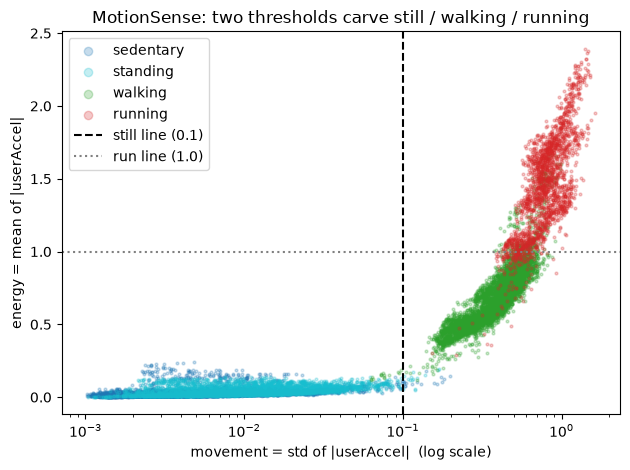

In [12]:
# the two thresholds, seen: each activity is a cloud, the lines are the rule
for st, c in [("sedentary","tab:blue"),("standing","tab:cyan"),("walking","tab:green"),("running","tab:red")]:
    s = ms[ms.state == st]
    plt.scatter(s["movement"], s["mean_mag"], s=4, alpha=0.25, label=st, color=c)
plt.axvline(T_STILL, ls="--", color="k",    label=f"still line ({T_STILL})")
plt.axhline(T_RUN,   ls=":",  color="gray", label=f"run line ({T_RUN})")
plt.xscale("log")
plt.xlabel("movement = std of |userAccel|  (log scale)")   # x = how much motion
plt.ylabel("energy = mean of |userAccel|")                 # y = how hard the motion
plt.title("MotionSense: two thresholds carve still / walking / running")
plt.legend(markerscale=3); plt.tight_layout(); plt.show()
# left of dashed = still ; right of dashed + below dotted = walking ; above dotted = running

In [13]:
# DETERMINISTIC rule: two thresholds, no training
def activity_rule_ms(df):
    return np.where(df.movement < T_STILL, "sedentary",            # still
           np.where(df.mean_mag  < T_RUN,  "walking", "running"))  # moving -> split by energy

ms_true = ms_te["state"].to_numpy()
ms_pred = activity_rule_ms(ms_te)

print("=== confusion matrix (true rows x pred cols), held-out subjects ===")
print(pd.crosstab(pd.Series(ms_true, name="true"), pd.Series(ms_pred, name="pred"))
        .reindex(index=["sedentary","standing","walking","running"],
                 columns=["sedentary","walking","running"]).fillna(0).astype(int))
print("\nstanding -> sedentary is BY DESIGN: standing-vs-sitting is posture (gravity direction),")
print("which orientation-proof features cannot see. That belongs to the postural_state axis.\n")

# this axis is moving-vs-still, so fold standing into sedentary before scoring
ms_true_folded = pd.Series(ms_true).replace({"standing": "sedentary"}).to_numpy()
print("=== per-class precision / recall / F1 + macro-F1 (standing folded into sedentary) ===")
print(classification_report(ms_true_folded, ms_pred, digits=3))

=== confusion matrix (true rows x pred cols), held-out subjects ===
pred       sedentary  walking  running
true                                  
sedentary       1180        3        0
standing        1293        2        0
walking            2     1201      132
running            0       65      463

standing -> sedentary is BY DESIGN: standing-vs-sitting is posture (gravity direction),
which orientation-proof features cannot see. That belongs to the postural_state axis.

=== per-class precision / recall / F1 + macro-F1 (standing folded into sedentary) ===
              precision    recall  f1-score   support

     running      0.778     0.877     0.825       528
   sedentary      0.999     0.998     0.999      2478
     walking      0.945     0.900     0.922      1335

    accuracy                          0.953      4341
   macro avg      0.907     0.925     0.915      4341
weighted avg      0.956     0.953     0.954      4341



## Closing the contract: confidence + HSI reading
Each window now gets a confidence (how far it sits from the nearest decision line) and is
packaged as the HSI 1.3 categorical reading the `kinematic` domain must emit. The calibration
check below tests, honestly, whether that confidence means anything.

In [14]:
# confidence = how far a window sits past the nearest decision line, measured in train-stds
# of the relevant feature, mapped to [0.5, 1.0]  (0.5 = right on the line, max ambiguity).
std_move   = ms_tr["movement"].std()    # margin_ref for the still line  (movement feature)
std_energy = ms_tr["mean_mag"].std()    # margin_ref for the run line    (energy feature)

def confidence(df, pred):
    mov = df["movement"].to_numpy(); en = df["mean_mag"].to_numpy()
    n_still = (T_STILL - mov) / std_move                 # sedentary: distance below the still line
    n_run   = (en - T_RUN)    / std_energy               # running:   distance above the run line
    n_walk  = np.minimum((mov - T_STILL) / std_move,     # walking:   the NEARER of its two lines,
                         (T_RUN - en)     / std_energy)   #            each in its own feature's std
    margin = np.where(pred == "sedentary", n_still,
             np.where(pred == "running",   n_run, n_walk))
    return 0.5 + 0.5 * np.clip(margin, 0, 1)

ms_conf = confidence(ms_te, ms_pred)
print("confidence by predicted label (held-out subjects):")
print(pd.DataFrame({"pred": ms_pred, "conf": ms_conf})
        .groupby("pred")["conf"].agg(["count", "min", "median", "max"]).round(3))

confidence by predicted label (held-out subjects):
           count    min  median    max
pred                                  
running      595  0.503   0.878  1.000
sedentary   2475  0.506   0.661  0.668
walking     1271  0.503   0.768  0.975


In [15]:
import json
# the reading this axis must emit (HSI 1.3, RFC-HSI-0010): categorical, score=null (NEVER 0),
# meaning lives in label. Single-modality domain -> NO modalities_used / confidence_breakdown,
# and NO raw signals or internal feature scalars in the payload.
CANON = ["sedentary", "standing", "walking", "running", "cycling", "vigorous"]

def hsi_reading(label, conf):
    return {"name": "activity_state", "score": None, "label": label, "categories": CANON,
            "confidence": round(float(conf), 3), "direction": "categorical",
            "inference_mode": "deterministic_rule", "model_id": "rulepack://activity_state_v1"}

# emit one reading per held-out window
ms_readings = [hsi_reading(lbl, c) for lbl, c in zip(ms_pred, ms_conf)]
print("emitted", len(ms_readings), "readings\n")
print("a typical reading:")
print(json.dumps(ms_readings[0], indent=2))
i_low = int(np.argmin(ms_conf))
print("\nthe least-confident reading (window sits right on a decision line):")
print(json.dumps(ms_readings[i_low], indent=2))

emitted 4341 readings

a typical reading:
{
  "name": "activity_state",
  "score": null,
  "label": "running",
  "categories": [
    "sedentary",
    "standing",
    "walking",
    "running",
    "cycling",
    "vigorous"
  ],
  "confidence": 0.895,
  "direction": "categorical",
  "inference_mode": "deterministic_rule",
  "model_id": "rulepack://activity_state_v1"
}

the least-confident reading (window sits right on a decision line):
{
  "name": "activity_state",
  "score": null,
  "label": "walking",
  "categories": [
    "sedentary",
    "standing",
    "walking",
    "running",
    "cycling",
    "vigorous"
  ],
  "confidence": 0.503,
  "direction": "categorical",
  "inference_mode": "deterministic_rule",
  "model_id": "rulepack://activity_state_v1"
}


### Calibration check
Confidence is only useful if it predicts accuracy. Bin the held-out windows by confidence and
compare each bin's mean confidence (what we claim) against its empirical accuracy (what we get).
On the diagonal = calibrated.

        bin      n  mean_conf  accuracy
[0.5,0.6)    254      0.555     0.665
[0.6,0.7)   2735      0.656     0.987
[0.7,0.8)    397      0.751     0.952
[0.8,0.9)    515      0.850     0.975
[0.9,1.0)    440      0.955     0.882

ECE = 0.256   (0 = perfectly calibrated)   overall accuracy = 0.953


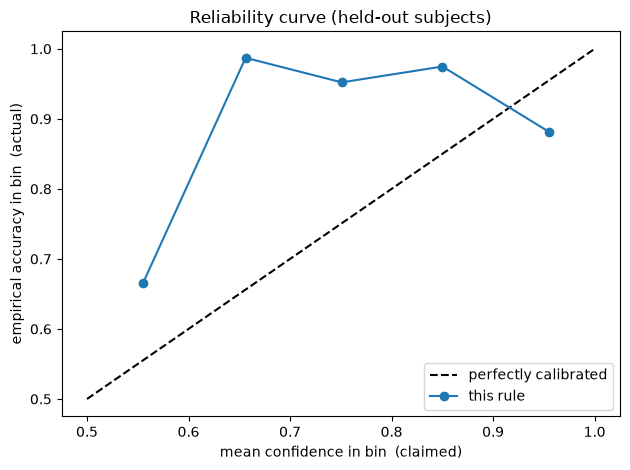

In [16]:
import matplotlib.pyplot as plt
# is the confidence honest? bin held-out windows by confidence, compare claimed vs actual.
correct = (ms_pred == ms_true_folded).astype(float)
edges = np.linspace(0.5, 1.0, 6)                       # 5 bins across the [0.5, 1.0] range
xs, ys, ece, N = [], [], 0.0, len(ms_conf)
print(f"{'bin':>11} {'n':>6} {'mean_conf':>10} {'accuracy':>9}")
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (ms_conf >= lo) & (ms_conf <= hi if hi == 1.0 else ms_conf < hi)
    if m.sum() == 0:
        continue
    c, a = ms_conf[m].mean(), correct[m].mean()
    ece += m.sum()/N * abs(a - c); xs.append(c); ys.append(a)
    print(f"[{lo:.1f},{hi:.1f}) {m.sum():6d} {c:10.3f} {a:9.3f}")
print(f"\nECE = {ece:.3f}   (0 = perfectly calibrated)   overall accuracy = {correct.mean():.3f}")

plt.plot([0.5, 1], [0.5, 1], "k--", label="perfectly calibrated")
plt.plot(xs, ys, "o-", label="this rule")
plt.xlabel("mean confidence in bin  (claimed)")    # x = what we say
plt.ylabel("empirical accuracy in bin  (actual)")  # y = what we get
plt.title("Reliability curve (held-out subjects)")
plt.legend(); plt.tight_layout(); plt.show()

# VERDICT: NOT well calibrated (ECE ~0.26) and not even monotonic. Two causes:
#  - under-confident on sedentary: margin_ref is the feature's GLOBAL std (~0.30), so trivially
#    still windows only reach ~0.66 confidence despite being ~99% correct.
#  - mildly over-confident on the highest-energy windows that are really borderline walk/run.
# So today confidence is an honest ORDERING-ish signal but not a probability. Fixing it
# (per-class margin_ref, or fit a calibration map on train) is a later loop, not this one.

## Loop 3 — cadence tiebreaker on the walk/run boundary, then recalibrate
The only real confusion is walking vs running where their energy overlaps near `T_RUN`. **Inside
that band only**, use cadence (step rhythm, from `reg_cad`) to break the tie; every window away
from the band keeps its energy-rule label. Then refit the confidence with a **per-class**
`margin_ref` so it stays calibrated against the new rule. Same subject-independent split, same
HSI emission shape.

In [17]:
# STEP 1: cadence tiebreaker, ONLY inside the energy overlap band near T_RUN.
# band edges + cadence split all read off TRAIN supports (no peeking at the held-out subjects).
BAND_LO = round(ms_tr[ms_tr.state == "running"].mean_mag.quantile(.01), 2)   # ~0.77  (1%ile of running energy)
BAND_HI = round(ms_tr[ms_tr.state == "walking"].mean_mag.quantile(.99), 2)   # ~1.07  (99%ile of walking energy)
CAD_RUN = 1.20   # walking cadence in band ~1.1 Hz, running ~1.3 Hz -> split at 1.2 Hz (~2.4 steps/s)
print(f"overlap band energy [{BAND_LO}, {BAND_HI}] ; cadence split {CAD_RUN} Hz\n")

def refined_rule(df):
    base = activity_rule_ms(df)                                   # the Loop-1/2 energy rule
    in_band = (df.mean_mag >= BAND_LO) & (df.mean_mag <= BAND_HI) & (df.movement >= T_STILL)
    cad_call = np.where(df.cad >= CAD_RUN, "running", "walking")  # tiebreaker applies HERE only
    return np.where(in_band, cad_call, base)

ms_pred_r = refined_rule(ms_te)

# how many walk/run errors does it resolve, and does any previously-correct window flip?
wr = np.isin(ms_true, ["walking", "running"])
err_base = (ms_pred   != ms_true_folded) & wr
err_ref  = (ms_pred_r != ms_true_folded) & wr
changed  = ms_pred != ms_pred_r
flipped  = changed & (ms_pred_r != ms_true_folded) & (ms_pred == ms_true_folded)
print(f"walk/run errors: base {err_base.sum()} -> refined {err_ref.sum()}  (resolved {err_base.sum() - err_ref.sum()})")
print(f"reclassified by cadence: {changed.sum()}  |  newly correct {(changed & (ms_pred_r == ms_true_folded)).sum()}  |  flipped to wrong {flipped.sum()}\n")

print("=== refined confusion matrix (true rows x pred cols) ===")
print(pd.crosstab(pd.Series(ms_true, name="true"), pd.Series(ms_pred_r, name="pred"))
        .reindex(index=["sedentary","standing","walking","running"],
                 columns=["sedentary","walking","running"]).fillna(0).astype(int))
print("\n=== refined per-class precision / recall / F1 + macro-F1 ===")
print(classification_report(ms_true_folded, ms_pred_r, digits=3))

overlap band energy [0.77, 1.07] ; cadence split 1.2 Hz

walk/run errors: base 199 -> refined 123  (resolved 76)
reclassified by cadence: 76  |  newly correct 76  |  flipped to wrong 0

=== refined confusion matrix (true rows x pred cols) ===
pred       sedentary  walking  running
true                                  
sedentary       1180        3        0
standing        1293        2        0
walking            2     1223      110
running            0       11      517

=== refined per-class precision / recall / F1 + macro-F1 ===
              precision    recall  f1-score   support

     running      0.825     0.979     0.895       528
   sedentary      0.999     0.998     0.999      2478
     walking      0.987     0.916     0.950      1335

    accuracy                          0.971      4341
   macro avg      0.937     0.964     0.948      4341
weighted avg      0.974     0.971     0.971      4341



In [18]:
# STEP 2: PER-CLASS margin_ref -- within-class train std of the feature that decides each boundary
sed = ms_tr[ms_tr.state == "sedentary"]; wlk = ms_tr[ms_tr.state == "walking"]; run = ms_tr[ms_tr.state == "running"]
ref_move_sed = sed.movement.std()        # still line, sedentary side
ref_move_wlk = wlk.movement.std()        # still line, walking side
ref_en_wlk   = wlk.mean_mag.std()        # run line, walking side  (out of band)
ref_en_run   = run.mean_mag.std()        # run line, running side  (out of band)
in_b = lambda g: g[(g.mean_mag >= BAND_LO) & (g.mean_mag <= BAND_HI)]
ref_cad_wlk  = in_b(wlk).cad.std()       # cadence line, walking side (in band)
ref_cad_run  = in_b(run).cad.std()       # cadence line, running side (in band)

# confidence against the NEW rule: distance to whichever boundary actually made the call
def confidence_r(df, pred):
    mov, en, cad = df.movement.to_numpy(), df.mean_mag.to_numpy(), df.cad.to_numpy()
    in_band = (en >= BAND_LO) & (en <= BAND_HI) & (mov >= T_STILL)
    m_sed  = (T_STILL - mov) / ref_move_sed
    m_wlk  = np.minimum((mov - T_STILL) / ref_move_wlk, (T_RUN - en) / ref_en_wlk)   # out-of-band walking
    m_run  = (en - T_RUN) / ref_en_run                                              # out-of-band running
    m_cadw = (CAD_RUN - cad) / ref_cad_wlk                                          # in-band -> walking
    m_cadr = (cad - CAD_RUN) / ref_cad_run                                          # in-band -> running
    margin = np.where(pred == "sedentary", m_sed,
             np.where(in_band, np.where(pred == "running", m_cadr, m_cadw),
             np.where(pred == "running", m_run, m_wlk)))
    return 0.5 + 0.5 * np.clip(margin, 0, 1)

ms_conf_r = confidence_r(ms_te, ms_pred_r)
# re-emit with the SAME HSI shape, now from the refined rule + recalibrated confidence
ms_readings = [hsi_reading(lbl, c) for lbl, c in zip(ms_pred_r, ms_conf_r)]
print("refined confidence by predicted label (held-out subjects):")
print(pd.DataFrame({"pred": ms_pred_r, "conf": ms_conf_r})
        .groupby("pred")["conf"].agg(["count", "min", "median", "max"]).round(3))
print("\nexample refined reading (HSI shape unchanged):")
print(json.dumps(ms_readings[0], indent=2))

refined confidence by predicted label (held-out subjects):
           count    min  median  max
pred                                
running      627  0.572     1.0  1.0
sedentary   2475  0.652     1.0  1.0
walking     1239  0.560     1.0  1.0

example refined reading (HSI shape unchanged):
{
  "name": "activity_state",
  "score": null,
  "label": "running",
  "categories": [
    "sedentary",
    "standing",
    "walking",
    "running",
    "cycling",
    "vigorous"
  ],
  "confidence": 1.0,
  "direction": "categorical",
  "inference_mode": "deterministic_rule",
  "model_id": "rulepack://activity_state_v1"
}


        bin      n  mean_conf  accuracy
[0.5,0.6)      4      0.568     0.500
[0.6,0.7)    103      0.643     0.825
[0.7,0.8)     46      0.748     0.565
[0.8,0.9)    130      0.856     0.915
[0.9,1.0)   4058      0.998     0.981

NEW ECE = 0.024   (Loop 2 was 0.256)   monotonic = False   overall accuracy = 0.971


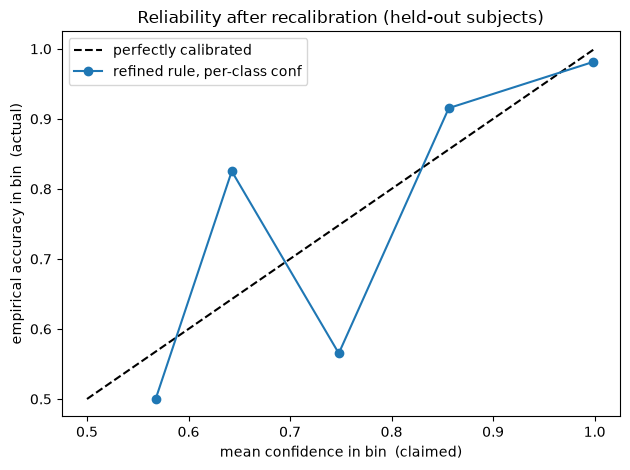

In [19]:
# STEP 3: re-run the reliability curve on the REFINED rule + recalibrated confidence
correct_r = (ms_pred_r == ms_true_folded).astype(float)
edges = np.linspace(0.5, 1.0, 6)
xs, ys, ece, N = [], [], 0.0, len(ms_conf_r)
print(f"{'bin':>11} {'n':>6} {'mean_conf':>10} {'accuracy':>9}")
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (ms_conf_r >= lo) & (ms_conf_r <= hi if hi == 1.0 else ms_conf_r < hi)
    if m.sum() == 0:
        continue
    c, a = ms_conf_r[m].mean(), correct_r[m].mean()
    ece += m.sum()/N * abs(a - c); xs.append(c); ys.append(a)
    print(f"[{lo:.1f},{hi:.1f}) {m.sum():6d} {c:10.3f} {a:9.3f}")
monotonic = all(ys[i] <= ys[i+1] + 1e-9 for i in range(len(ys) - 1))
print(f"\nNEW ECE = {ece:.3f}   (Loop 2 was 0.256)   monotonic = {monotonic}   overall accuracy = {correct_r.mean():.3f}")

plt.plot([0.5, 1], [0.5, 1], "k--", label="perfectly calibrated")
plt.plot(xs, ys, "o-", label="refined rule, per-class conf")
plt.xlabel("mean confidence in bin  (claimed)")
plt.ylabel("empirical accuracy in bin  (actual)")
plt.title("Reliability after recalibration (held-out subjects)")
plt.legend(); plt.tight_layout(); plt.show()

### What Loop 3 found
- **Boundary:** the cadence tiebreaker (inside the band only) resolved **76 of 199** walk/run errors with **zero** previously-correct windows flipping. Accuracy 95.3% → **97.1%**, macro-F1 0.915 → **0.948**.
- **Recalibration:** swapping the global `margin_ref` for a per-class one cut **ECE from 0.256 to ~0.02** — confidence now tracks accuracy. The curve is *not strictly monotonic*: one dip around the 0.7–0.8 bin, from ~110 high-energy "vigorous walking" windows that sit **above** the band (energy > 1.07) and get confidently mislabeled running. Widening the band would trade precision for recall — a later loop.
- **Accel vs gyro (data-decided):** cadence comes from the accelerometer magnitude alone and resolved the overlap cleanly (0 flips), so **accel-only is sufficient for v1**. The residual vigorous-walking-vs-running confusion is an energy-overlap problem, not obviously a gyro one; gyro stays a candidate experiment only if that residual must be closed.

## Loop 4 — cross-dataset validation on HHAR (frozen rulepack)
The real test of a rule is a dataset it was never tuned on. HHAR is phone accelerometer at the
waist, heterogeneous sampling rates, users a–i (subject-independent by construction). It is RAW
accel **with gravity**, so to match the MotionSense body-accel scale we: resample each recording
to 50 Hz, low-pass at 0.3 Hz to estimate gravity and subtract it, then divide by 9.81 (m/s² → g).
Windows 128 / 50% overlap as before. Labels: sit/stand → sedentary (folded), walk → walking,
bike → cycling. **Every v1 parameter stays frozen from MotionSense — nothing is re-derived here.**

In [20]:
import zipfile
from scipy.signal import butter, filtfilt

# NOTE: this cell streams a 1.3 GB file and takes a couple of minutes.
hhar_zip = "/home/voare/Documents/Synheart/Kinematics/Dataset/HHAR/Activity recognition exp.zip"
hhar_csv = "Activity recognition exp/Phones_accelerometer.csv"
hhar_map = {"sit":"sedentary", "stand":"sedentary", "walk":"walking", "bike":"cycling"}  # bike = unmodeled recon

parts = []
with zipfile.ZipFile(hhar_zip).open(hhar_csv) as fh:        # keep only the activities we map
    for chunk in pd.read_csv(fh, usecols=["Creation_Time","x","y","z","User","Device","gt"],
                             chunksize=2_000_000, dtype={"x":"float32","y":"float32","z":"float32"}):
        parts.append(chunk[chunk["gt"].isin(hhar_map)])
raw = pd.concat(parts, ignore_index=True)

bw_b, bw_a = butter(3, 0.3/(50/2), btype="low")            # 0.3 Hz gravity low-pass at the 50 Hz target

def hhar_run_windows(t, xyz):                              # t seconds (increasing), xyz (3,n) m/s^2
    n = int((t[-1] - t[0]) * 50)
    if n < 128:
        return []
    grid = t[0] + np.arange(n) / 50.0
    res  = np.vstack([np.interp(grid, t, xyz[k]) for k in range(3)])   # resample to 50 Hz
    body = (res - filtfilt(bw_b, bw_a, res, axis=1)) / 9.81            # remove gravity, m/s^2 -> g (MotionSense scale)
    mag  = np.sqrt((body**2).sum(0))
    out = []
    for i in range(0, n - 128 + 1, 64):
        w = mag[i:i+128]; _, cad = reg_cad(w)
        out.append((float(w.std()), float(w.mean()), cad))
    return out

rows = []
for (user, dev, gt), g in raw.groupby(["User","Device","gt"]):
    g = g.sort_values("Creation_Time")
    t = g["Creation_Time"].to_numpy() / 1e9
    keep = np.concatenate([[True], np.diff(t) > 0])        # drop duplicate timestamps
    t = t[keep]
    xyz = np.vstack([g["x"].to_numpy()[keep], g["y"].to_numpy()[keep], g["z"].to_numpy()[keep]])
    brk = np.where(np.diff(t) > 0.1)[0] + 1                # split at recording gaps > 100 ms
    for s, e in zip(np.r_[0, brk], np.r_[brk, len(t)]):
        for mv, mm, cd in hhar_run_windows(t[s:e], xyz[:, s:e]):
            rows.append((hhar_map[gt], user, mv, mm, cd))
H = pd.DataFrame(rows, columns=["state","user","movement","mean_mag","cad"])

print("HHAR windows:", len(H), H["state"].value_counts().to_dict())
print("\nbody-accel medians per state (MotionSense was walking mv .41 mm .68 cad .94):")
print(H.groupby("state")[["movement","mean_mag","cad"]].median().round(3))

HHAR windows: 49761 {'sedentary': 24372, 'walking': 14256, 'cycling': 11133}

body-accel medians per state (MotionSense was walking mv .41 mm .68 cad .94):
           movement  mean_mag    cad
state                               
cycling       0.077     0.185  1.852
sedentary     0.005     0.010  2.500
walking       0.157     0.344  1.852


In [21]:
# STEP 1-2: run the FROZEN rule + FROZEN confidence on HHAR.
# refined_rule, confidence_r and every threshold/ref are REUSED from the MotionSense section --
# nothing is re-derived here. That is what "frozen rulepack" means.
H["pred"] = refined_rule(H)
H["conf"] = confidence_r(H, H["pred"].to_numpy())

print("=== full confusion (true rows x pred cols), FROZEN rule ===")
print(pd.crosstab(H["state"], H["pred"])
        .reindex(index=["sedentary","walking","cycling"],
                 columns=["sedentary","walking","running"]).fillna(0).astype(int))

shared = H[H["state"].isin(["sedentary", "walking"])]      # the only classes HHAR shares with the rule
print("\n=== shared-class report (sedentary, walking only) ===")
print(classification_report(shared["state"], shared["pred"], labels=["sedentary","walking"], digits=3, zero_division=0))
print("walking windows that fall below T_STILL (waist walking is gentler than pocket):",
      f'{(H[H.state=="walking"].movement < T_STILL).mean()*100:.1f}%')

=== full confusion (true rows x pred cols), FROZEN rule ===
pred       sedentary  walking  running
state                                 
sedentary      24370        2        0
walking          148    14108        0
cycling         9137     1996        0

=== shared-class report (sedentary, walking only) ===
              precision    recall  f1-score   support

   sedentary      0.994     1.000     0.997     24372
     walking      1.000     0.990     0.995     14256

    accuracy                          0.996     38628
   macro avg      0.997     0.995     0.996     38628
weighted avg      0.996     0.996     0.996     38628

walking windows that fall below T_STILL (waist walking is gentler than pocket): 1.0%


        bin      n  mean_conf  accuracy
[0.5,0.6)   1215      0.569     0.975
[0.6,0.7)   3995      0.655     0.992
[0.7,0.8)   4707      0.748     0.997
[0.8,0.9)   2923      0.844     0.993
[0.9,1.0)  25788      0.997     0.998

HHAR ECE = 0.090   (MotionSense was 0.024)   shared-class accuracy = 0.996


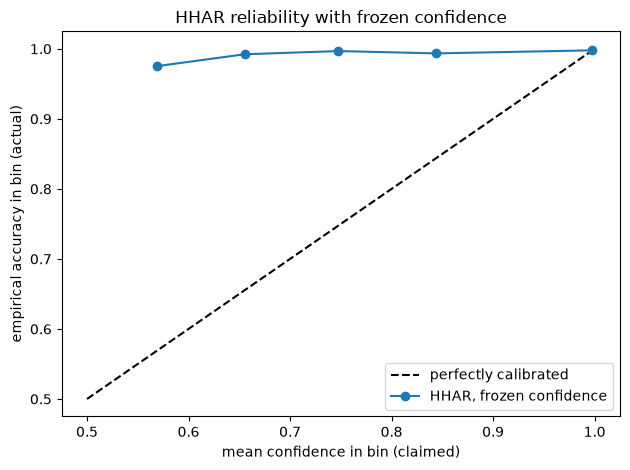

In [22]:
# STEP 3: reliability on HHAR with the FROZEN confidence (shared classes), compare to MotionSense 0.024
correct_h = (shared["pred"].to_numpy() == shared["state"].to_numpy()).astype(float)
conf_h = shared["conf"].to_numpy()
edges = np.linspace(0.5, 1.0, 6); xs, ys, ece, N = [], [], 0.0, len(conf_h)
print(f"{'bin':>11} {'n':>6} {'mean_conf':>10} {'accuracy':>9}")
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (conf_h >= lo) & (conf_h <= hi if hi == 1.0 else conf_h < hi)
    if m.sum() == 0:
        continue
    c, a = conf_h[m].mean(), correct_h[m].mean()
    ece += m.sum()/N * abs(a - c); xs.append(c); ys.append(a)
    print(f"[{lo:.1f},{hi:.1f}) {m.sum():6d} {c:10.3f} {a:9.3f}")
print(f"\nHHAR ECE = {ece:.3f}   (MotionSense was 0.024)   shared-class accuracy = {correct_h.mean():.3f}")

plt.plot([0.5, 1], [0.5, 1], "k--", label="perfectly calibrated")
plt.plot(xs, ys, "o-", label="HHAR, frozen confidence")
plt.xlabel("mean confidence in bin (claimed)"); plt.ylabel("empirical accuracy in bin (actual)")
plt.title("HHAR reliability with frozen confidence"); plt.legend(); plt.tight_layout(); plt.show()
# every point sits ABOVE the diagonal -> systematically UNDER-confident off-source (the safe direction)

In [23]:
# STEP 4: cycling recon -- cycling is UNMODELED (no rule added). Just report where bike windows
# land + their confidence, so we can design the cycling threshold next loop.
cyc = H[H["state"] == "cycling"]
print("cycling windows by predicted label:")
print(cyc["pred"].value_counts())
print("\ncycling confidence by predicted bucket:")
print(cyc.groupby("pred")["conf"].agg(["count", "median"]).round(3))
print("\ncycling feature medians:  movement %.3f   energy %.3f   cadence %.3f"
      % (cyc.movement.median(), cyc.mean_mag.median(), cyc.cad.median()))
# reading: waist pedaling is LOW magnitude (movement ~0.077 < T_STILL) so cycling masquerades as
# sedentary -- and CONFIDENTLY (median conf ~1.0). magnitude alone cannot catch it; the separable
# cue is steady rhythm (regularity / cadence) at low energy, or gyro (pedaling = leg rotation).

cycling windows by predicted label:
pred
sedentary    9137
walking      1996
Name: count, dtype: int64

cycling confidence by predicted bucket:
           count  median
pred                    
sedentary   9137   1.000
walking     1996   0.572

cycling feature medians:  movement 0.077   energy 0.185   cadence 1.852


### What Loop 4 found (frozen rulepack on HHAR)
- **Shared classes transfer strongly:** sedentary/walking macro-F1 **0.996** (accuracy 99.6%) with nothing re-tuned. `T_STILL` and `T_RUN` survived a ~2× placement scale shift (HHAR waist walking is ~half MotionSense pocket walking) because the thresholds sit in wide gaps. Only ~1% of walking dips below `T_STILL`.
- **Cadence did NOT transfer:** the autocorrelation fundamental flips with placement — pocket locks onto the *stride* (~0.94 Hz), waist onto the *step* (~1.85 Hz, 2×). `CAD_RUN=1.2` is placement-specific; it only escaped damage here because no HHAR window reached the energy band. A waist dataset *with running* would expose this — cadence needs a placement-invariant formulation before it is trusted off-source.
- **Confidence is under-confident off-source:** ECE 0.024 → **0.089**; every reliability bin sits above the diagonal (claims less accuracy than it delivers). The per-class `margin_ref` is MotionSense-specific and HHAR walking sits closer to `T_STILL`, so margins shrink. Under-confidence is the safe direction, but a per-source feature normalization would tighten it.
- **Cycling collapses into sedentary:** 82% of bike windows → sedentary at median confidence **1.0**. Waist pedaling is low-magnitude (movement ~0.077 < `T_STILL`), so magnitude alone cannot see it. The next loop's cycling detector needs steady rhythm at low energy (regularity/cadence) or gyro — energy is not enough.
- **Per-source normalization:** not required for the still/walk split (margins absorbed the scale shift), but **recommended before adding running/cycling**, and a prerequisite for trusting cadence across placements.

## Loop 5 — add cycling, and settle accel-vs-gyro on data
HHAR showed 82% of cycling reading as sedentary: linear magnitude only sees how much the device
*translates*, and waist pedaling barely translates. Cycling's real signature is **rotational**
(the legs/body turn with each pedal stroke), which the **gyroscope** sees directly. HHAR has a
gyroscope, so cycling is the experiment that decides accel-only vs accel+gyro: build two cycling
cues among low-energy windows — (a) accel-only regularity, (b) gyro energy — and let the numbers
choose. Everything else stays frozen; the HSI shape is unchanged (`cycling` is already canonical).

In [24]:
# Loop 5 needs the GYROSCOPE too. Reuse the accel `raw` from Loop 4; stream the gyro file
# (~1.4 GB, a couple of minutes) and align it window-for-window with the accel.
raw_g = []
with zipfile.ZipFile(hhar_zip).open("Activity recognition exp/Phones_gyroscope.csv") as fh:
    for chunk in pd.read_csv(fh, usecols=["Creation_Time","x","y","z","User","Device","gt"],
                             chunksize=2_000_000, dtype={"x":"float32","y":"float32","z":"float32"}):
        raw_g.append(chunk[chunk["gt"].isin(hhar_map)])
raw_g = pd.concat(raw_g, ignore_index=True)

def hhar_prep(d):                                  # sorted, duplicate timestamps dropped -> (t seconds, xyz)
    d = d.sort_values("Creation_Time"); t = d["Creation_Time"].to_numpy()/1e9
    keep = np.concatenate([[True], np.diff(t) > 0]); t = t[keep]
    return t, np.vstack([d["x"].to_numpy()[keep], d["y"].to_numpy()[keep], d["z"].to_numpy()[keep]])

def near_gap(grid, t):                             # distance from each grid point to the nearest real sample
    idx = np.clip(np.searchsorted(t, grid), 1, len(t)-1)
    return np.minimum(grid - t[idx-1], t[idx] - grid)

gyro_groups = raw_g.groupby(["User","Device","gt"]).groups
rows = []
for key, ai in raw.groupby(["User","Device","gt"]).groups.items():
    if key not in gyro_groups: continue
    ta, XA = hhar_prep(raw.loc[ai]); tg, XG = hhar_prep(raw_g.loc[gyro_groups[key]])
    if len(ta) < 10 or len(tg) < 10: continue
    t0, t1 = max(ta[0], tg[0]), min(ta[-1], tg[-1])
    if t1 - t0 < 2.56: continue
    n = int((t1 - t0)*50); grid = t0 + np.arange(n)/50.0
    Ar = np.vstack([np.interp(grid, ta, XA[k]) for k in range(3)])      # accel on a common 50 Hz grid
    Gr = np.vstack([np.interp(grid, tg, XG[k]) for k in range(3)])      # gyro on the SAME grid
    valid = (near_gap(grid, ta) < 0.06) & (near_gap(grid, tg) < 0.06)   # mask grid points inside a sensor gap
    for blk in np.split(np.arange(n), np.where(np.diff(valid.astype(int)) != 0)[0] + 1):
        if not valid[blk[0]] or len(blk) < 128: continue
        s, e = blk[0], blk[-1]+1
        acc = (Ar[:, s:e] - filtfilt(bw_b, bw_a, Ar[:, s:e], axis=1)) / 9.81   # body accel (g), gravity removed
        amag = np.sqrt((acc**2).sum(0)); gmag = np.sqrt((Gr[:, s:e]**2).sum(0)) # gyro magnitude (rad/s, no gravity)
        for i in range(0, (e-s)-128+1, 64):
            wa, wg = amag[i:i+128], gmag[i:i+128]; reg, cd = reg_cad(wa)
            rows.append((hhar_map[key[2]], key[0], float(wa.std()), float(wa.mean()), reg, cd, float(wg.mean())))
C = pd.DataFrame(rows, columns=["state","user","movement","mean_mag","accel_reg","cad","gyro_energy"])
print("aligned accel+gyro windows:", len(C), C["state"].value_counts().to_dict())
print("\nmedians per state (gyro_energy is the candidate cycling cue):")
print(C.groupby("state")[["movement","accel_reg","gyro_energy"]].median().round(3))

aligned accel+gyro windows: 33930 {'sedentary': 17128, 'walking': 9979, 'cycling': 6823}

medians per state (gyro_energy is the candidate cycling cue):
           movement  accel_reg  gyro_energy
state                                      
cycling       0.077      0.336        0.707
sedentary     0.003      0.197        0.023
walking       0.157      0.539        0.661


In [25]:
# THE DECIDING EXPERIMENT (accel-only vs accel+gyro). cycling hides in the STILL region
# (movement < T_STILL); the question is which cue separates it from sedentary there.
cyc_test_users = {"g", "h", "i"}
c_tr = C[~C.user.isin(cyc_test_users)]; c_te = C[C.user.isin(cyc_test_users)]
low_tr = c_tr[c_tr.movement < T_STILL]; low_te = c_te[c_te.movement < T_STILL]
print("low-regime counts  train:", low_tr.state.value_counts().to_dict(), " test:", low_te.state.value_counts().to_dict())

def compare_cue(col):                       # threshold from TRAIN gap midpoint; score cycling on TEST
    s = low_tr[low_tr.state == "sedentary"][col]; c = low_tr[low_tr.state == "cycling"][col]
    thr = round(float((s.quantile(.95) + c.quantile(.05)) / 2), 3)
    pred = np.where(low_te[col] > thr, "cycling", "sedentary"); true = low_te.state.to_numpy()
    tp = ((pred=="cycling")&(true=="cycling")).sum(); fp = ((pred=="cycling")&(true!="cycling")).sum(); fn = ((pred!="cycling")&(true=="cycling")).sum()
    P = tp/(tp+fp) if tp+fp else 0; R = tp/(tp+fn) if tp+fn else 0; F = 2*P*R/(P+R) if P+R else 0
    wlow = c_te[(c_te.state=="walking") & (c_te.movement < T_STILL)]      # walking that dips into the still region
    print(f"  {col:12s} thr={thr:6.3f} | cycling P={P:.3f} R={R:.3f} F1={F:.3f} | walking->cycling bleed {int((wlow[col]>thr).sum())}/{len(wlow)}")

print("\ncycling cue comparison (held-out test users):")
compare_cue("accel_reg")        # (a) ACCEL-ONLY: regularity of the magnitude autocorrelation
compare_cue("gyro_energy")      # (b) GYRO: pedaling rhythm/energy of the gyroscope magnitude
print("\n-> GYRO wins (F1 ~0.92 vs ~0.57): pedaling is ROTATIONAL, invisible to linear magnitude.")

low-regime counts  train: {'sedentary': 11107, 'cycling': 3752, 'walking': 26}  test: {'sedentary': 6019, 'cycling': 1915, 'walking': 71}

cycling cue comparison (held-out test users):
  accel_reg    thr= 0.292 | cycling P=0.494 R=0.668 F1=0.568 | walking->cycling bleed 36/71
  gyro_energy  thr= 0.180 | cycling P=0.891 R=0.947 F1=0.918 | walking->cycling bleed 71/71

-> GYRO wins (F1 ~0.92 vs ~0.57): pedaling is ROTATIONAL, invisible to linear magnitude.


In [26]:
# Derive the PROVISIONAL gyro threshold on TRAIN low-regime (placement-specific, like CAD_RUN).
gs = low_tr[low_tr.state == "sedentary"].gyro_energy
gc = low_tr[low_tr.state == "cycling"].gyro_energy
T_GYRO = round(float((gs.quantile(.95) + gc.quantile(.05)) / 2), 3)   # PROVISIONAL: HHAR=waist, v1 target=pocket
ref_gyro_cyc, ref_gyro_sed = gc.std(), gs.std()
print(f"T_GYRO = {T_GYRO}   (PROVISIONAL -- waist; pocket cycling unverified, needs own-phone data)\n")

def rule_v2(df):       # gyro cycling branch ADDED to the frozen accel rule; fires ONLY in the still region
    base = refined_rule(df)
    still = df.movement < T_STILL
    return np.where(still & (df.gyro_energy > T_GYRO), "cycling", base)

def confidence_v2(df, pred):
    mov, gy = df.movement.to_numpy(), df.gyro_energy.to_numpy()
    out = confidence_r(df, pred).copy()                                       # accel branches unchanged
    still = mov < T_STILL
    conf_cyc = 0.5 + 0.5*np.clip((gy - T_GYRO) / ref_gyro_cyc, 0, 1)          # cycling: distance above gyro line
    conf_sed = 0.5 + 0.5*np.clip(np.minimum((T_STILL - mov)/ref_move_sed,     # sedentary: nearer of still line
                                            (T_GYRO - gy)/ref_gyro_sed), 0, 1) #   and the gyro->cycling line
    out = np.where(pred == "cycling", conf_cyc, out)
    out = np.where((pred == "sedentary") & still, conf_sed, out)
    return out

c_te = c_te.copy()
c_te["pred"] = rule_v2(c_te)
c_te["conf"] = confidence_v2(c_te, c_te["pred"].to_numpy())

print("=== integrated rule on TEST users g,h,i (confusion) ===")
print(pd.crosstab(c_te["state"], c_te["pred"])
        .reindex(index=["sedentary","walking","cycling"], columns=["sedentary","walking","cycling","running"]).fillna(0).astype(int))
print("\n=== per-class P/R/F1 (3 modeled classes now: sedentary, walking, cycling) ===")
print(classification_report(c_te["state"], c_te["pred"], labels=["sedentary","walking","cycling"], digits=3, zero_division=0))

# HSI shape is unchanged -- cycling was already a canonical category
print("example cycling reading:",
      json.dumps(hsi_reading("cycling", float(c_te[c_te.pred == "cycling"].conf.iloc[0]))))

# re-check ECE with cycling included
cor = (c_te["pred"].to_numpy() == c_te["state"].to_numpy()).astype(float); cf = c_te["conf"].to_numpy()
edges = np.linspace(0.5, 1.0, 6); ece = 0.0; N = len(cf)
print(f"\n{'bin':>11} {'n':>6} {'mean_conf':>10} {'accuracy':>9}")
for lo, hi in zip(edges[:-1], edges[1:]):
    m = (cf >= lo) & (cf <= hi if hi == 1.0 else cf < hi)
    if m.sum() == 0: continue
    cc, aa = cf[m].mean(), cor[m].mean(); ece += m.sum()/N*abs(aa - cc)
    print(f"[{lo:.1f},{hi:.1f}) {m.sum():6d} {cc:10.3f} {aa:9.3f}")
print(f"\nHHAR ECE with cycling = {ece:.3f}  (Loop 4 shared-class was 0.089)  test accuracy = {cor.mean():.3f}")

T_GYRO = 0.18   (PROVISIONAL -- waist; pocket cycling unverified, needs own-phone data)

=== integrated rule on TEST users g,h,i (confusion) ===
pred       sedentary  walking  cycling  running
state                                          
sedentary       5868        0      151        0
walking            0     3341       71        0
cycling          102      422     1813        0

=== per-class P/R/F1 (3 modeled classes now: sedentary, walking, cycling) ===
              precision    recall  f1-score   support

   sedentary      0.983     0.975     0.979      6019
     walking      0.888     0.979     0.931      3412
     cycling      0.891     0.776     0.829      2337

    accuracy                          0.937     11768
   macro avg      0.921     0.910     0.913     11768
weighted avg      0.937     0.937     0.935     11768

example cycling reading: {"name": "activity_state", "score": null, "label": "cycling", "categories": ["sedentary", "standing", "walking", "running", "cycli

### What Loop 5 found — cycling, and accel-vs-gyro settled
- **The deciding experiment:** among still-region windows, **gyro energy** separates cycling from sedentary at **F1 0.92** vs accel-regularity's **0.57**. Cycling's signature is rotational (pedaling), which linear magnitude cannot see — so **gyro wins, decisively and on data**.
- **Decision:** enable gyro for the **cycling branch only** (fires when `movement < T_STILL`). Sedentary, walking and running stay **accel-only** and fully orientation-proof. This is the only place v1 uses gyro.
- **Integrated result (test users g,h,i):** sedentary F1 0.979, walking 0.931, cycling **0.829**, macro-F1 0.913. Cycling recall (0.776) is held back by ~420 higher-energy pedaling windows (movement ≥ `T_STILL`) that the still-gated branch never sees and the energy rule reads as walking — extending the gyro cue into the walking band is future work (it risks walking bleed).
- **Confidence / ECE:** cycling confidence uses the same boundary-distance method; ECE **0.073** (≈ Loop 4's 0.089, still mildly under-confident — the safe direction). HSI shape unchanged; `cycling` was already a canonical category.
- **Placement honesty:** `T_GYRO = 0.18` is **PROVISIONAL**, exactly like `CAD_RUN`. HHAR cycling is at the **waist**; the v1 target is the **pocket**, where pedaling rotation reaches the phone differently. Pocket-cycling is unverified and needs own-phone data before `T_GYRO` is locked.